In [28]:
import pandas as pd

In [7]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATASET_DIR = Path("./Data/Classmates_Clean")
MODEL_PATH = Path("../models/face_detection_yunet_2026may.onnx")
ALIGNED_DIR = Path("./Data/Classmates_Aligned")

ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

print("Clean dataset:", DATASET_DIR.resolve())
print("YuNet model:", MODEL_PATH.resolve())
print("Aligned output:", ALIGNED_DIR.resolve())

Clean dataset: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Classmates_Clean
YuNet model: D:\Artificial intelligence\projects\FaceRecognisationSystem\models\face_detection_yunet_2026may.onnx
Aligned output: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Classmates_Aligned


In [8]:
DATASET_DIR = Path("./Data/Classmates_Clean")
MODEL_PATH = Path("./models/face_detection_yunet_2026may.onnx")
ALIGNED_DIR = Path("./Data/Classmates_Aligned")

In [9]:
# Load YuNet

detector = cv2.FaceDetectorYN.create(
    model=str(MODEL_PATH),
    config="",
    input_size=(320, 320),
    score_threshold=0.6,
    nms_threshold=0.3,
    top_k=5000
)

print("YuNet loaded successfully.")

YuNet loaded successfully.


In [10]:
# test alignment on 1 image

# Select one clean image for alignment testing

test_path = DATASET_DIR / "Nikhil_Kanbarkar" / "NK2.jpeg"

print("Test image:", test_path)
print("Exists:", test_path.exists())

Test image: Data\Classmates_Clean\Nikhil_Kanbarkar\NK2.jpeg
Exists: True


Image shape: (1040, 780, 3)


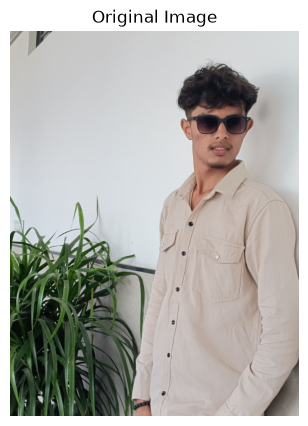

In [11]:
# Load and desplay the images

image = cv2.imread(str(test_path))

if image is None:
    raise ValueError(f"Could not read image: {test_path}")

print("Image shape:", image.shape)

plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

In [12]:
# detect the face

h, w = image.shape[:2]

# YuNet expects (width, height)
detector.setInputSize((w, h))

_, faces = detector.detect(image)

if faces is None:
    raise ValueError("YuNet could not detect a face.")

print("Faces detected:", len(faces))

Faces detected: 1


In [13]:
# Select the face

face = max(
    faces,
    key=lambda f: f[14]
)

print("Detection confidence:", face[14])

Detection confidence: 0.93396443


In [14]:
# Extract th 5 Landmarks 

landmarks = face[4:14].reshape(5, 2)

print("5 facial landmarks:")
print(landmarks)

5 facial landmarks:
[[539.7329  247.82428]
 [603.86206 251.23975]
 [576.4768  287.05966]
 [540.8902  315.6576 ]
 [595.59955 318.30646]]


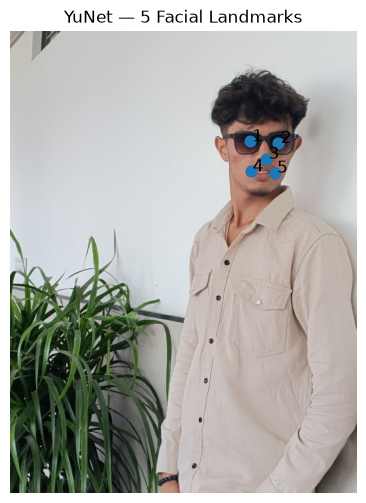

In [15]:
# visualisation of the landmarks

plt.figure(figsize=(8, 6))

plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)

plt.scatter(
    landmarks[:, 0],
    landmarks[:, 1],
    s=60
)

for i, (x, y) in enumerate(landmarks, start=1):
    plt.text(
        x + 5,
        y,
        str(i),
        fontsize=12
    )

plt.title("YuNet — 5 Facial Landmarks")
plt.axis("off")
plt.show()

In [16]:
# Define ArcFace's Reference Templet

ARC_FACE_TEMPLATE = np.array([
    [38.2946, 51.6963],  # Right eye
    [73.5318, 51.5014],  # Left eye
    [56.0252, 71.7366],  # Nose
    [41.5493, 92.3655],  # Right mouth
    [70.7299, 92.2041]   # Left mouth
], dtype=np.float32)

print(ARC_FACE_TEMPLATE)

[[38.2946 51.6963]
 [73.5318 51.5014]
 [56.0252 71.7366]
 [41.5493 92.3655]
 [70.7299 92.2041]]


In [17]:
# create the alignment Function

def align_face(image, landmarks):
    
    landmarks = np.asarray(
        landmarks,
        dtype=np.float32
    )

    transform, _ = cv2.estimateAffinePartial2D(
        landmarks,
        ARC_FACE_TEMPLATE,
        method=cv2.LMEDS
    )

    if transform is None:
        return None

    aligned = cv2.warpAffine(
        image,
        transform,
        (112, 112),
        borderMode=cv2.BORDER_CONSTANT
    )

    return aligned

In [18]:
# Align the face

aligned = align_face(
    image,
    landmarks
)

if aligned is None:
    raise ValueError("Face alignment failed.")

print("Aligned image shape:", aligned.shape)

Aligned image shape: (112, 112, 3)


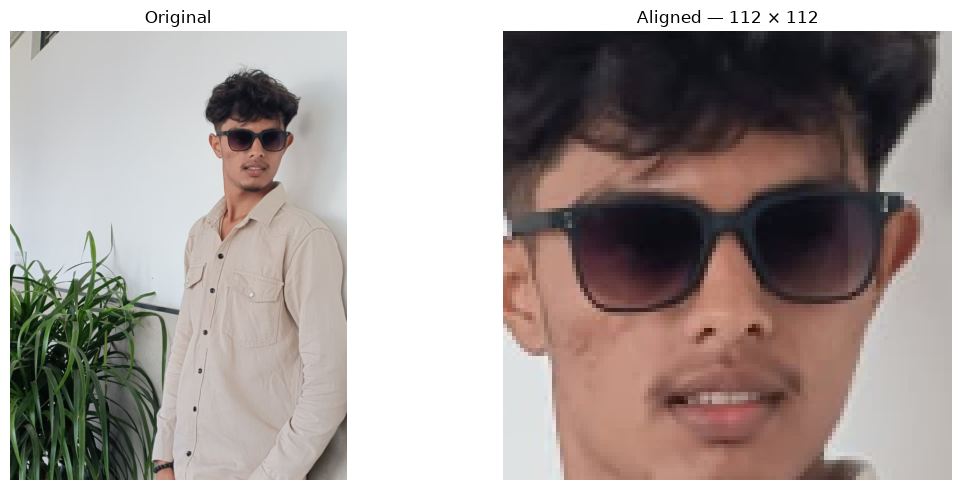

In [19]:
# compare original vs Aligned

plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)

plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)

plt.title("Original")
plt.axis("off")


# Aligned
plt.subplot(1, 2, 2)

plt.imshow(
    cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)
)

plt.title("Aligned — 112 × 112")
plt.axis("off")

plt.tight_layout()
plt.show()

## For All Clean Images

In [20]:
# Make sure the output directory exists

ALIGNED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Aligned output directory:", ALIGNED_DIR.resolve())

Aligned output directory: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Classmates_Aligned


Define the alignment pipeline

We'll create a function that:

* Reads an image
* Runs YuNet
* Requires exactly one face
* Extracts the 5 landmarks
* Aligns the face
* Returns the aligned 112×112 image

In [22]:
def process_single_image(image_path):

    image = cv2.imread(str(image_path))

    if image is None:
        return None, "IMAGE_READ_FAILED"

    h, w = image.shape[:2]

    # YuNet expects (width, height)
    detector.setInputSize((w, h))

    _, faces = detector.detect(image)

    if faces is None:
        return None, "NO_FACE"

    if len(faces) != 1:
        return None, "MULTIPLE_FACES"

    face = faces[0]

    # Extract 5 landmarks
    landmarks = face[4:14].reshape(5, 2)

    # Align
    aligned = align_face(
        image,
        landmarks
    )

    if aligned is None:
        return None, "ALIGNMENT_FAILED"

    return aligned, "SUCCESS"

In [23]:
# Process all images

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

success_count = 0
failed_count = 0

failure_records = []

for person_dir in sorted(DATASET_DIR.iterdir()):

    if not person_dir.is_dir():
        continue

    output_person_dir = ALIGNED_DIR / person_dir.name
    output_person_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    image_paths = [
        p for p in person_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    print(f"\nProcessing {person_dir.name}...")

    for image_path in sorted(image_paths):

        aligned, status = process_single_image(
            image_path
        )

        if status == "SUCCESS":

            output_path = (
                output_person_dir /
                image_path.name
            )

            # Save aligned image
            cv2.imwrite(
                str(output_path),
                aligned
            )

            success_count += 1

        else:

            failed_count += 1

            failure_records.append({
                "person": person_dir.name,
                "filename": image_path.name,
                "status": status
            })

print("\n========== COMPLETE ==========")
print("Successful:", success_count)
print("Failed:", failed_count)


Processing Abhishek_Halagi...

Processing Darshan_Khadakhadi...

Processing Darshan_Netegal...

Processing Dhurvankur_...

Processing Harshad_Bhairatkar...

Processing Mahesh_Oulkar...

Processing Nikhil_Kanbarkar...

Processing Pranav_Kavale...

Processing Rohan_Kamble...

Processing Rohit_Patil...

Processing Sahil_Kurbet...

Processing Sahil_Patil...

Processing Suraj_Mallur...

Processing Vishwanath_Muchandi...

========== COMPLETE ==========
Successful: 213
Failed: 27


In [25]:
# Verify the number of aligned images

aligned_count = sum(
    1
    for p in ALIGNED_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
)

print("Aligned images:", aligned_count)

Aligned images: 213


In [26]:
# Verify every aligned image is 112×112×3

invalid_shapes = []

for image_path in ALIGNED_DIR.rglob("*"):

    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    image = cv2.imread(str(image_path))

    if image is None:
        invalid_shapes.append(
            (str(image_path), "READ_FAILED")
        )
        continue

    if image.shape != (112, 112, 3):
        invalid_shapes.append(
            (str(image_path), image.shape)
        )

print("Invalid aligned images:", len(invalid_shapes))

if invalid_shapes:
    for item in invalid_shapes[:10]:
        print(item)

Invalid aligned images: 0


In [29]:
# Verify the number of images per person
aligned_counts = {}

for person_dir in sorted(ALIGNED_DIR.iterdir()):

    if not person_dir.is_dir():
        continue

    count = sum(
        1
        for p in person_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    )

    aligned_counts[person_dir.name] = count

aligned_counts_df = pd.Series(
    aligned_counts,
    name="aligned_images"
)

print(aligned_counts_df)

Abhishek_Halagi        17
Darshan_Khadakhadi     15
Darshan_Netegal        12
Dhurvankur_            22
Harshad_Bhairatkar     16
Mahesh_Oulkar          10
Nikhil_Kanbarkar       25
Pranav_Kavale           6
Rohan_Kamble            6
Rohit_Patil            24
Sahil_Kurbet            5
Sahil_Patil            30
Suraj_Mallur           14
Vishwanath_Muchandi    11
Name: aligned_images, dtype: int64


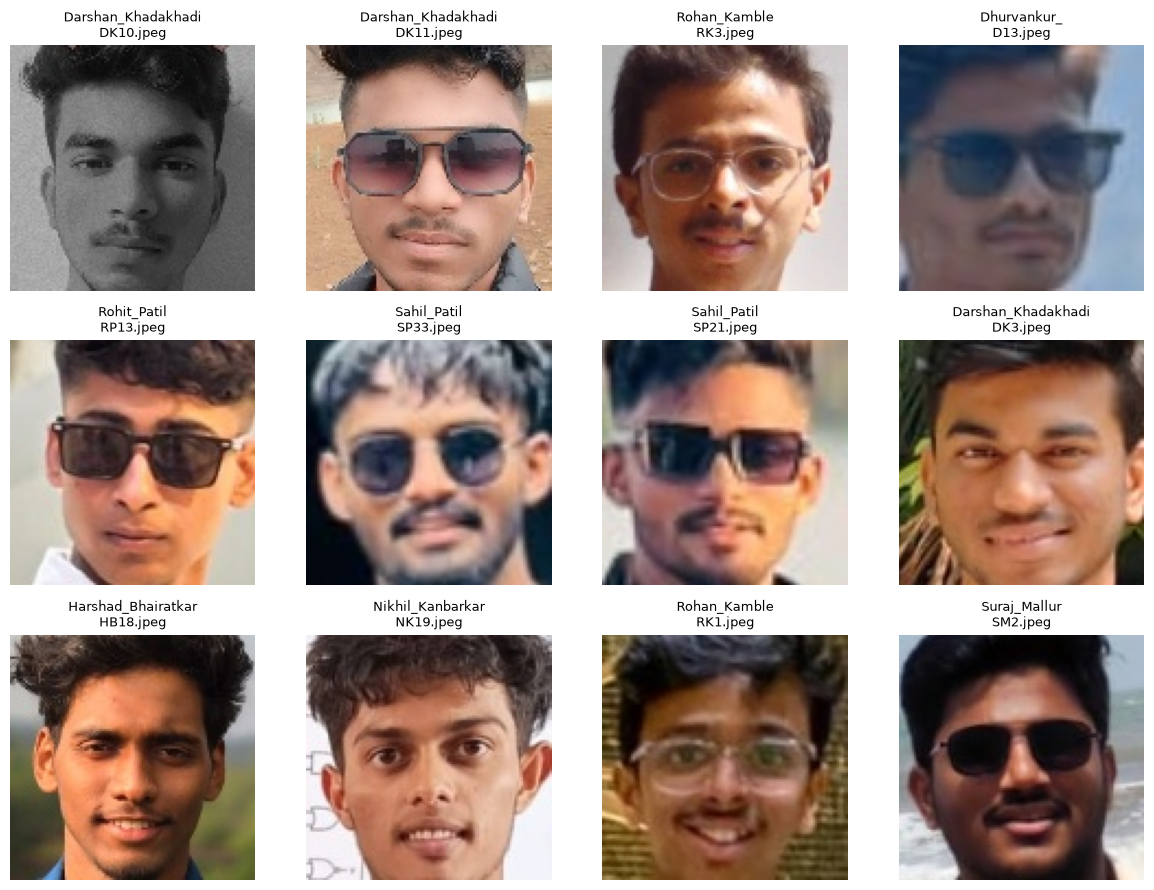

In [30]:
# Visually inspect random aligned faces
import random

aligned_images = [
    p
    for p in ALIGNED_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
]

sample_paths = random.sample(
    aligned_images,
    min(12, len(aligned_images))
)

plt.figure(figsize=(12, 9))

for i, path in enumerate(sample_paths):

    image = cv2.imread(str(path))
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(3, 4, i + 1)
    plt.imshow(image_rgb)

    plt.title(
        f"{path.parent.name}\n{path.name}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()